In [21]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)

In [22]:
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

In [23]:
df = pd.read_csv("EDA_dataset.csv")
df = df[df['year'] == 2025]

print(f"Total Reviews : {len(df):,}")

df.head()

Total Reviews : 59,996


,reviewId,content,score,at,bank,year
0,46a9b775-12db-4cad-a259-83bdd6ff5b78,bca gaje sinyal bagus tapi merah mulu,1,2025-12-30 19:24:57,BCAMOBILE_REVIEWS,2025
1,fb449431-50de-41a5-9809-df47d670ee2a,apa ini aplikasi bintang 1.. register mobile banking dari pagi Ampe sore bilangnya tunggu indikator hijau... pdahal tidak ada indikator sama sekali Ampe habis pulsa gue 20k,1,2025-12-30 19:23:00,BCAMOBILE_REVIEWS,2025
2,1390039e-cd94-4046-b864-523acc647bc9,akun nya ga bis akembali,1,2025-12-30 17:11:35,BCAMOBILE_REVIEWS,2025
3,5fa82eb0-e111-4a8f-b397-8a6fd37d1709,makin paraaaaaah setelah diupdate .aplikasi nya ya Allah,1,2025-12-30 16:51:09,BCAMOBILE_REVIEWS,2025
4,6881a68b-b85e-4ba0-9d8b-d5a2c21a6ca4,"indikator lampu merah terus , mana sering gitu Mulu lagi, setiap mau dipakek kayak gitu Mulu, sampai berjam2 pada hak sinyal bagus, apk udah diperbarui. kejadian terus berulang² dan sering",1,2025-12-30 16:02:42,BCAMOBILE_REVIEWS,2025


dataset overview

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59996 entries, 0 to 59995
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  59996 non-null  object
 1   content   59996 non-null  object
 2   score     59996 non-null  int64 
 3   at        59996 non-null  object
 4   bank      59996 non-null  object
 5   year      59996 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 2.7+ MB


Rating Distribution

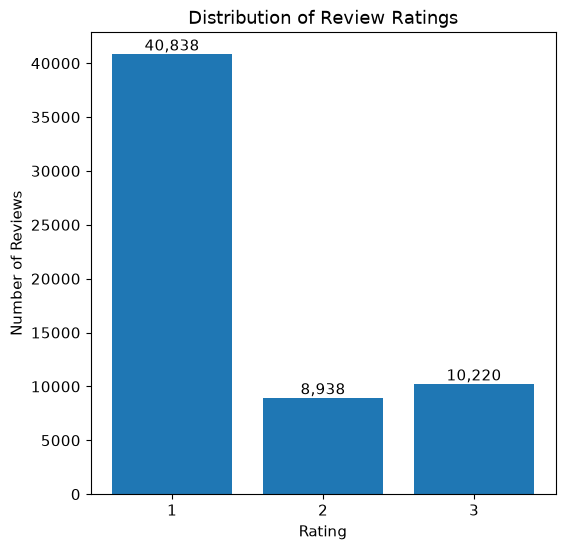

In [25]:
rating_count = (
    df["score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,6))

plt.bar(
    rating_count.index.astype(str),
    rating_count.values
)

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

for i, v in enumerate(rating_count.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.show()

most of the reviews dominated with 1 stars which is what we're hoping for for this research

Review Length (Characters)

In [26]:
df["character_length"] = (
    df["content"]
    .astype(str)
    .str.len()
)

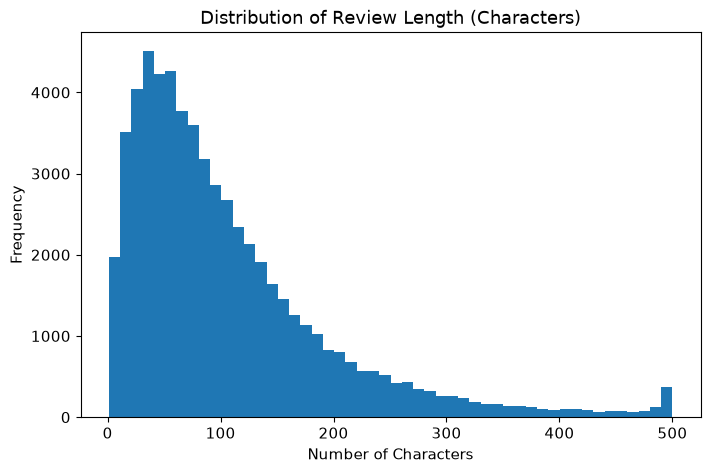

In [27]:
plt.figure(figsize=(8,5))

plt.hist(
    df["character_length"],
    bins=50
)

plt.title("Distribution of Review Length (Characters)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()


Review Length (Words)

In [28]:
df["word_length"] = (
    df["content"]
    .astype(str)
    .str.split()
    .str.len()
)

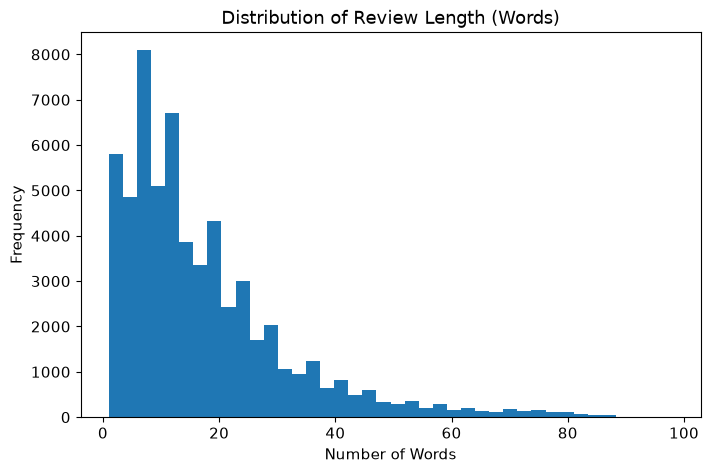

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    df["word_length"],
    bins=40
)

plt.title("Distribution of Review Length (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

short reviews 

In [30]:
df[
    df["word_length"] <= 3
][["content"]].head(20)

,content
9,sampah
21,mkain lemot
67,susah masuk login
73,aplikasi kacau
76,aplikasi buruk
95,merah terus !!!
96,jaringan merah mulu
136,potongan gak jelas!!
139,Aplikasi sering gangguan
155,sangat bagus


longest reviews

In [31]:
df.nlargest(
    20,
    "word_length"
)[["word_length","content"]]

,word_length,content
17848,98,"saya mau isi saldo shoopay kok susah sekali ya, kalau mau isi saldo 2 juta aja ribet amat, hari ini trfer 1 juta pkek @wallet bisa, ntar kelang brpa jam gk bisa lagi. trz aku tfer 5rtus ribu bis, stlh itu gk bisa lagi, trz kirim lagi 3ratus bisa, trs sisanya mau trfer 2 ratus gk bisa lagi, jadi aku tf 100rbu bisa, mau tf lgi gk bisa lagi. adu pusing ya susah bner mau trfer ke shoopay aja ribet gitu. sebelumnya gk ada masalah mau tf brpa aja ke shoopay. sekarang ribet pusing gk tau salahnya dimna"
19912,98,"suruh buka rek di aplikasi brimo. awal pas di dkt satpam bisa di buka dan suruh isi dana 50rb abis itu blm sempat ketemu cs. kata satpam rek sdh bisa d gunakan. ok dong saya gak perlu ke cs karena klu tunggu cs katanya nanti jm3. hakirnya gue balik setelah berhasil gue tf 50rb ke rek yg baru gue buka. bsk nya gue mau buka aplikasi brimo tiba"" udh gk bisa di buka.sampe gue ke bank tdk di layanin dng baik. gue pake bca udh 20thn gak pernah ada kendala kaya bri dan dilayani dengan baik di bca"
43428,96,"awal nya laporan hp hilang, mu dftr livin baru. dengan nomor hp yg berbeda dr yg sblomnya .. eh malah nunggu 2 minggu . lama amaaatt beuh,BCA hr itu juga bisa ko . laporan hp hilang,lgsng bikin mbanking baru dgn krtu yg berbeda nah bca mah langsung bisa . ini ko dftar livin hrus nunggu 2 mnggu . ga gercep banget ,mana pas buka livin ko tiba2 ke blokir .baru jg smnggu dftar livin ,suruh nunggu 2 mnggu.1 mnggu aja ke blokir pas mu buka livin . ribet bnget sumpah ih mandiri. gabisa gercep kaya BCA"
36054,95,"sangat menyusahkan di era digital , krtu atm hilang , hrs k cabang , pengurusan atm 3 hr baru jd hrs bolak balik ke bank , di livin tidak bisa login , hrs k cabang lagi , sangat2 kesulitan , yg lain bikin atm bisa online , atm hilng/rusk bisa bikin online , atm di antr k alamat domisili , hanya video call 10 mnt beres , di lngkapi call senter bebas pls , sbnr nya dlm pengunaan sama aja , krna orng bnyk sibuk nya mngkin lbh baik bralih ke yg lbh mudah .."
45489,95,"Hingga saat ini apk Livin saya tidak bisa login lagi. Ntah apa masalah GK tau, bantuan cs nya juga GK ada di apk Livin. Jadi Livin itu seolah² GK ada gunanya. Bahkan juga GK berfungsi lagi. Apk nya hanya jadi pajangan saja di hp saya. Coba deh Livin itu jadi lebih baik lagi, masak saya tiba² GK bisa login. GK logika gitu. Data sudah saya masukin dengan benar. Tapi yg muncul data salah. Pusing gua. Udah dikluarin tiba² aja dari apk nya. Tolong di bantu lah. Uang masuk & kluar pun kita JD GK tau"
35425,94,"ni aplikasi dan bank gak bagus, selalu jam 12 malem eror, bank gak bisa 24 jam, ni gak patut nabung di sini bahaya, bgmna kalau org tua atau keluarga ada yg sakit dan minta tolong soal biaya di jam 12 malem, yg ada org bisa meninggal urusan nya, selalu eror dan gak layak buat di tabung ni bank mandiri, jangan lagi kawan2 tabung di bank mandiri, susah in org trus, setiap jam 12 jam 1 pasti eror, sekarang aja Uda eror 3 x, sya mau tutup rekening aja di mandiri, bank yg gak profesional,"
52068,94,aplikasi wondr payah hp ke reset sama anak pas mau masuk lagi suruh isi data KTP sama kartu ATM udah di isi semua pas terakhir foto Selfi kaga bisa bisa bolak balik masuk udah 3 hari kaga bisa juga cuma gara gara Selfi mata kedip kedip ga bisa juga sampe cape tiap hari pagi sore masih kaga bisa juga kan seharusnya asal data sesuai KTP sama kartu atm-nya sesuai udah ini malah di bikin ribet cuma Selfi ga berhasil terus kedipin mata coba sini depan cs gw kedipin mata pasti klepek klepek jatuh cint
17104,93,"jangan download apk ini abng2 ,fitur cs nya rusak ,udh tau chat cs nyari Soli biar gak Dateng k kantor eh si cs mlh nyuruh Dateng ke kantor mending klo masalah nya yg ribet mah ,masalah kecil juga langsung di suruh k kantor ,mending sekarang uang kalian yg ada di ATM cepet2 ambil deh keburu di blokir sama pihak bank sebulan 2 bulan GK ada transaksi blokir ditarik gak bisa giliran di isi gercep no lelet no slow respon ,fiks akhir jaman ,penipu ses

checking weird comments

In [32]:
df["content"].str.fullmatch(r"[A-Za-z\s.,!?]+", na=False).value_counts()

content
True     40234
False    19762
Name: count, dtype: int64

In [33]:
df[
    df["content"].str.len() < 30
][["content"]].sample(30, random_state=42)

,content
54308,lelet terlalu lelet
22679,Gak bisa qris selalu gagal
57400,mantap
48997,Error mu gblok
16432,kenapa brimoku tidak aktif?
33063,mau login aja sering gangguan
10573,sangat bagus
42044,ngga bisa update
15572,buka aplikasi lama
10114,force close


bank distribution

In [34]:
bank_count = (
    df["bank"]
    .value_counts()
    .sort_values(ascending=False)
)

bank_count

bank
BRIMO_REVIEWS            21112
LIVIN_MANDIRI_REVIEWS    16485
WONDR_BNI_REVIEWS        13619
BCAMOBILE_REVIEWS         8780
Name: count, dtype: int64

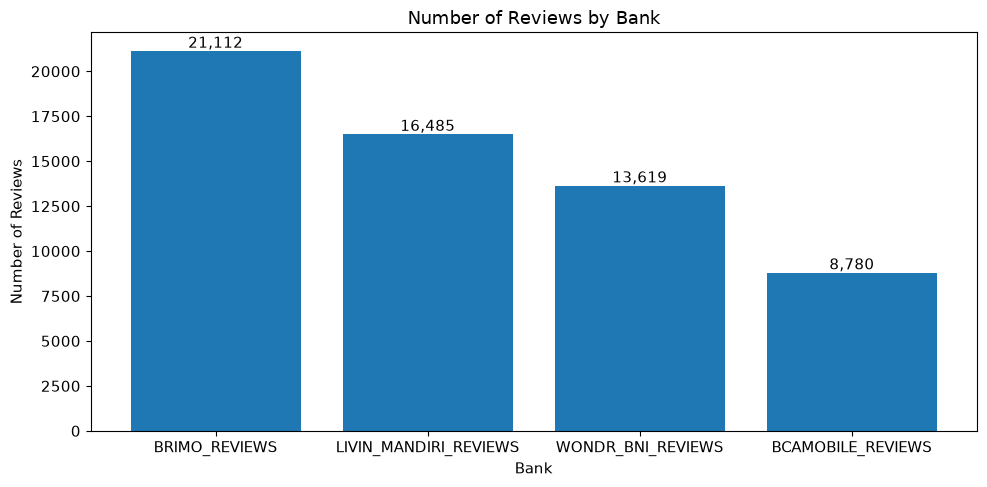

In [35]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    bank_count.index,
    bank_count.values
)

plt.title("Number of Reviews by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

pie chart per bank by percentage

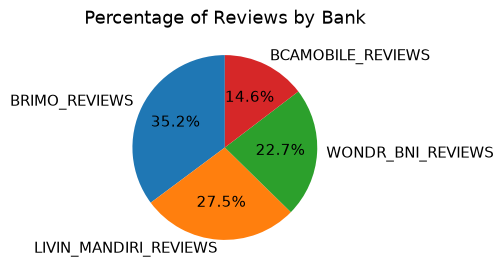

In [36]:
plt.figure(figsize=(3,3))

plt.pie(
    bank_count.values,
    labels=bank_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Reviews by Bank")

plt.show()